In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import warnings
warnings.filterwarnings('ignore')
sns.set(style='darkgrid')

In [3]:
df = pd.read_csv('AutoInsurance.csv')

In [4]:
df.head()

,Customer,State,Customer Lifetime Value,Response,Coverage,Education,Effective To Date,EmploymentStatus,Gender,Income,...,Months Since Policy Inception,Number of Open Complaints,Number of Policies,Policy Type,Policy,Renew Offer Type,Sales Channel,Total Claim Amount,Vehicle Class,Vehicle Size
0,BU79786,Washington,2763.519279,No,Basic,Bachelor,2/24/11,Employed,F,56274,...,5,0,1,Corporate Auto,Corporate L3,Offer1,Agent,384.811147,Two-Door Car,Medsize
1,QZ44356,Arizona,6979.535903,No,Extended,Bachelor,1/31/11,Unemployed,F,0,...,42,0,8,Personal Auto,Personal L3,Offer3,Agent,1131.464935,Four-Door Car,Medsize
2,AI49188,Nevada,12887.431650,No,Premium,Bachelor,2/19/11,Employed,F,48767,...,38,0,2,Personal Auto,Personal L3,Offer1,Agent,566.472247,Two-Door Car,Medsize
3,WW63253,California,7645.861827,No,Basic,Bachelor,1/20/11,Unemployed,M,0,...,65,0,7,Corporate Auto,Corporate L2,Offer1,Call Center,529.881344,SUV,Medsize
4,HB64268,Washington,2813.692575,No,Basic,Bachelor,3/2/2011,Employed,M,43836,...,44,0,1,Personal Auto,Personal L1,Offer1,Agent,138.130879,Four-Door Car,Medsize


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9134 entries, 0 to 9133
Data columns (total 24 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Customer                       9134 non-null   object 
 1   State                          9134 non-null   object 
 2   Customer Lifetime Value        9134 non-null   float64
 3   Response                       9134 non-null   object 
 4   Coverage                       9134 non-null   object 
 5   Education                      9134 non-null   object 
 6   Effective To Date              9134 non-null   object 
 7   EmploymentStatus               9134 non-null   object 
 8   Gender                         9134 non-null   object 
 9   Income                         9134 non-null   int64  
 10  Location Code                  9134 non-null   object 
 11  Marital Status                 9134 non-null   object 
 12  Monthly Premium Auto           9134 non-null   i

In [6]:
df.isnull().sum().sum()

np.int64(0)

In [ ]:
df['Customer Lifetime Value'].describe().astype(int)

count     9134
mean      8004
std       6870
min       1898
25%       3994
50%       5780
75%       8962
max      83325
Name: Customer Lifetime Value, dtype: int64

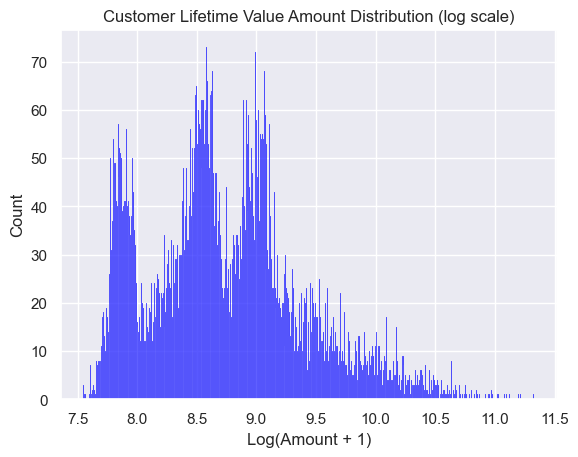

In [8]:
sns.histplot(np.log1p(df['Customer Lifetime Value']), bins=500, kde= False, color='blue')
plt.title('Customer Lifetime Value Amount Distribution (log scale)')
plt.xlabel('Log(Amount + 1)')
plt.show()

In [ ]:
df['Effective To Date'] = pd.to_datetime(df['Effective To Date'])
df['Last_Month'] = df['Effective To Date'].dt.month

In [ ]:
df['Target_NonResponse'] = df['Response'].apply(lambda x: 1 if x == 'No' else 0)

In [ ]:
df['Target_NonResponse'].value_counts()
#Finding the rate at which people don't respond

Target_NonResponse
1    7826
0    1308
Name: count, dtype: int64

Text(0.5, 0, 'Month as number')

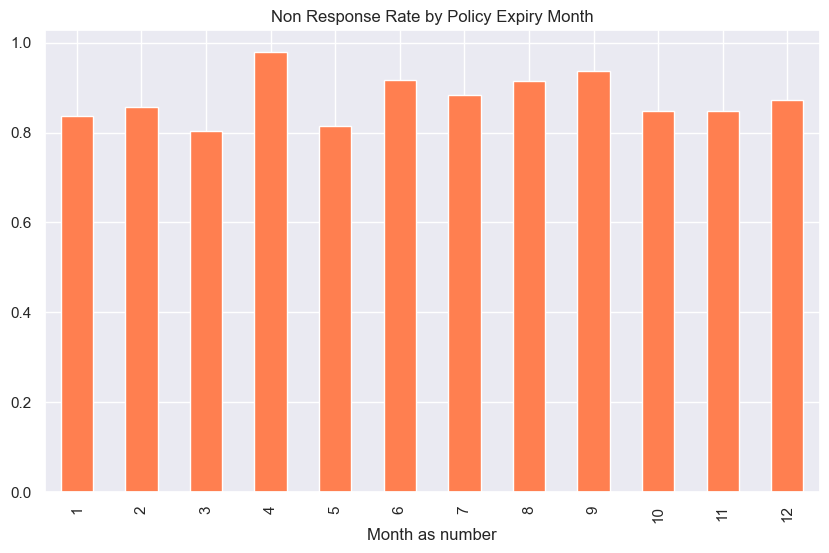

In [12]:
#Visualizing non response rate by month
monthly_NoResponse = df.groupby('Last_Month')['Target_NonResponse'].mean()
plt.figure(figsize=(10,6))
monthly_NoResponse.plot(kind='bar', color='coral')
plt.title('Non Response Rate by Policy Expiry Month')
plt.xlabel('Month as number')

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

In [ ]:
df_modelX = df.drop(columns=['Customer','Effective To Date', 'Response', 'Target_NonResponse'])
df_modelY = df['Target_NonResponse']

In [ ]:
print(df_modelY.value_counts(normalize=True))

Target_NonResponse
1    0.856799
0    0.143201
Name: proportion, dtype: float64


In [ ]:
numeric = ['Customer Lifetime Value',
                     'Income', 'Monthly Premium Auto', 'Months Since Last Claim',
                       'Months Since Policy Inception', 'Number of Open Complaints',
                       'Number of Policies',
                       'Total Claim Amount', 'Last_Month']


In [ ]:
categorical = ['State', 'Coverage', 'Education', 'EmploymentStatus', 
                        'Gender', 'Location Code', 'Marital Status', 'Policy Type', 'Policy', 'Renew Offer Type', 
                        'Sales Channel', 'Vehicle Class', 'Vehicle Size']

In [ ]:
categorical_transformer = Pipeline(steps=[('onehot', OneHotEncoder(handle_unknown='ignore'))])

In [ ]:
preprocessor = ColumnTransformer(transformers=[('numeric', 'passthrough', numeric),('categorical', categorical_transformer, categorical)])

In [ ]:
pipeline = Pipeline(steps=[('preprocessor', preprocessor),('classifier', RandomForestClassifier(n_estimators=100, max_depth=10, class_weight='balanced', random_state=42, n_jobs=-1))])

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(df_modelX,df_modelY, test_size=0.2, random_state=42, stratify=df_modelY)
#Split data to 80% training 20% prediction

In [ ]:
pipeline.fit(X_train, Y_train)

TypeError: All estimators should implement fit and transform, or can be 'drop' or 'passthrough' specifiers. 'Passthrough' (type <class 'str'>) doesn't.

In [ ]:
Y_pred = pipeline.predict(X_test)
Y_pred_proba = pipeline.predict_proba(X_test)[:, 1]
print(classification_report(Y_test,Y_pred, target_names=['Will Respond', 'Won\'t Respond']))
print(round(roc_auc_score(Y_test, Y_pred_proba), 4))

               precision    recall  f1-score   support

 Will Respond       0.69      1.00      0.82       262
Won't Respond       1.00      0.93      0.96      1565

     accuracy                           0.94      1827
    macro avg       0.85      0.96      0.89      1827
 weighted avg       0.96      0.94      0.94      1827

0.9966


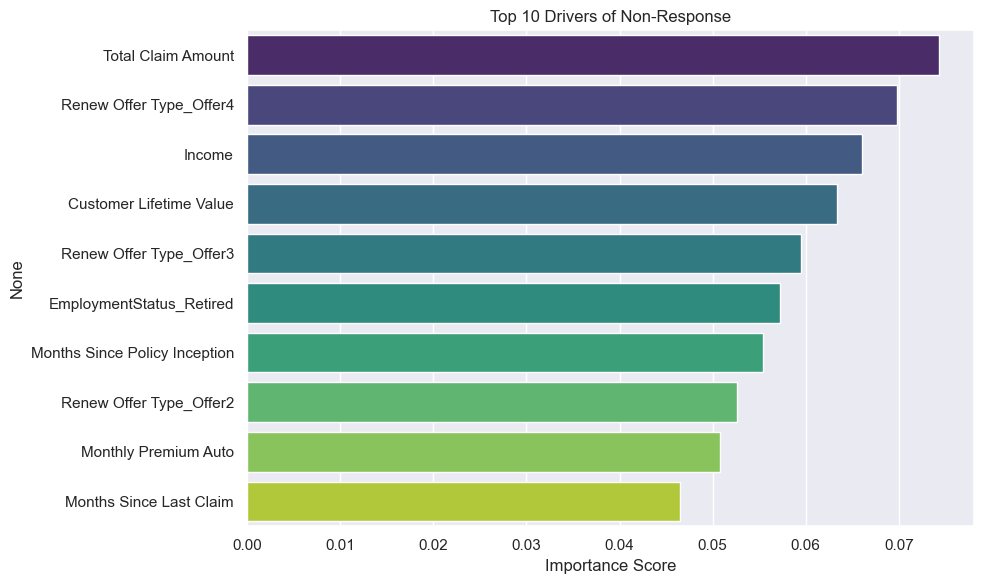

In [ ]:
encoded_cat_names = pipeline.named_steps['preprocessor'].transformers_[1][1].get_feature_names_out(categorical)
all_feature_names = numeric + list(encoded_cat_names)
importances = pipeline.named_steps['classifier'].feature_importances_
feat_imp = pd.Series(importances, index=all_feature_names).sort_values(ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x=feat_imp.values[:10], y=feat_imp.index[:10], palette='viridis')
plt.title('Top 10 Drivers of Non-Response')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()